# HapSleep — PoC multi-wearable (A + B) · **ensayo exploratorio, no es resultado final**

**Para qué:** que la app funcione con Fitbit, Galaxy Watch, Xiaomi y Amazfit sin tener un modelo distinto por marca.
Este notebook ensaya dos cosas:

- **Parte A — ¿cuánto cuesta la universalidad?** Se entrena el modelo solo con las variables que cada reloj entregaría
  y se compara con el modelo completo (mismo protocolo que POC 1.3 y el POC final).
- **Parte B — prototipo de la capa de estandarización.** Un pipeline que recibe los datos "en el idioma" de cada marca
  (con nombres y unidades distintas y datos sucios), los limpia, detecta qué variables hay, elige el modelo que
  corresponde y devuelve el nivel de riesgo con su calidad de datos.

**Lo que este notebook NO mide (importante):** las diferencias reales entre los algoritmos de cada fabricante. Solo
tenemos datos de Fitbit (LifeSnaps). Aquí se *simula* que un reloj entrega menos variables, pero los valores siguen
siendo de Fitbit. Comprobar que un Xiaomi mide "lo mismo" que un Fitbit requiere datos de esos relojes (ver la
verificación física pendiente en `variables_por_plataforma.md`).

**Otras salvedades:** la etiqueta sigue siendo el proxy (puntaje de sueño de Fitbit, 37 personas); los perfiles por
marca salen de una tabla con fuentes parcialmente secundarias y sin verificar físicamente.

In [1]:
import sys, json, warnings
from pathlib import Path
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("../POC1/data/daily_fitbit_sema_df_unprocessed.csv")
COL_ID, LABEL_COL, SEED = "id", "sleep_points_percentage", 42
N_FOLDS, N_REPEATS, MIN_NIGHTS = 5, 20, 10          # 10 noches: menos que eso fue ruidoso en poc1
PSQI_CUT_LEVE, PSQI_CUT_ALTO, SCALE = 5, 10, 21     # mismos cortes y reescala que el POC final (ensayo)

FULL = ["rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate", "minutesToFallAsleep",
        "minutesAsleep", "minutesAwake", "sleep_efficiency", "steps", "sedentary_minutes"]

# Variables que cada reloj entregaría, según la tabla de variables_por_plataforma.md.
# Criterio conservador: solo lo confirmado o derivable; lo dudoso ("?") se deja fuera.
PROFILES = {
    "Fitbit (Google Health API)": FULL,
    "Fitbit (Health Connect)": [v for v in FULL if v not in ("sedentary_minutes", "nremhr", "minutesToFallAsleep")],
    "Galaxy Watch FE": ["minutesAsleep", "sleep_efficiency", "resting_hr", "steps", "spo2"],
    "Xiaomi Band 9": ["minutesAsleep", "sleep_efficiency", "resting_hr", "steps"],
    "Amazfit Bip 5": ["minutesAsleep", "sleep_efficiency", "resting_hr"],
}


def fname(v, stat):
    return "sleep_duration_inconsistency" if (v == "minutesAsleep" and stat == "std") else f"{v}_{stat}"


def feat_cols(vs):
    return [fname(v, s) for v in vs for s in ("mean", "std")]


def risk_level(index):
    s = index * SCALE
    return "Leve" if s <= PSQI_CUT_LEVE else ("Moderado" if s <= PSQI_CUT_ALTO else "Alto")


# --- cohorte: las 37 personas con puntaje real (igual que POC 1.3 y POC final) ---
df = pd.read_csv(DATA_PATH)
for c in FULL + [LABEL_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
has = df.groupby(COL_ID)[LABEL_COL].apply(lambda s: s.notna().any())
raw37 = df[df[COL_ID].isin(has[has].index)].copy()
assert not raw37.duplicated([COL_ID, "date"]).any()

rows = []
for pid, g in raw37.groupby(COL_ID):
    r = {COL_ID: pid, "label": g[LABEL_COL].mean()}
    for v in FULL:
        r[fname(v, "mean")], r[fname(v, "std")] = g[v].mean(), g[v].std()
    rows.append(r)
person_raw = pd.DataFrame(rows)                               # sin imputar
allcols = feat_cols(FULL)
person = person_raw.copy()
person[allcols] = person[allcols].fillna(person[allcols].median())   # relleno con mediana (igual que antes)
y = (1 - person["label"]).reset_index(drop=True)
y_alto = (y * SCALE > PSQI_CUT_ALTO).astype(int)
ids = person[COL_ID].reset_index(drop=True)
print(f"Personas: {len(person)} | con nivel real Alto: {int(y_alto.sum())} ({y_alto.mean():.0%})")

Personas: 37 | con nivel real Alto: 11 (30%)


## Parte A — ¿Cuánto se pierde con las variables que entrega cada reloj?

Perfiles (qué variables recibiría el modelo con cada reloj, según la investigación previa):

| Perfil | Variables | Nota |
|---|---|---|
| Fitbit (Google Health API) | las 11 | El modelo completo |
| Fitbit (Health Connect) | 8 | Sin minutos sedentarios (no existen en Health Connect); sin latencia ni pulso no-REM (dudosos) |
| Galaxy Watch FE | 5 | Sueño, eficiencia, pulso en reposo, pasos, SpO2 |
| Xiaomi Band 9 | 4 | "Núcleo común": sueño, eficiencia, pulso en reposo, pasos |
| Amazfit Bip 5 | 3 | Pasos no confirmados en su app: solo sueño y pulso |
| Núcleo común + minutos despierto | 5 | Extra: qué se gana si el reloj también entrega minutos despierto |
| Diagnóstico: completo sin sedentarios | 10 | Extra: aísla el efecto de perder solo los minutos sedentarios |
| Diagnóstico: núcleo común + sedentarios | 5 | Extra: qué se recupera si el núcleo tuviera minutos sedentarios |

Cada fila se evalúa igual que en POC 1.3: Random Forest, 5-Fold × 20 repeticiones, sobre personas no vistas. Métricas:
Spearman (¿ordena bien?), error medio (MAE) y ROC-AUC para separar el nivel **Alto** (la regla del POC final). El
baseline es un modelo que siempre predice el promedio (ROC-AUC = 0.5).

In [2]:
def repeated_cv(vs):
    Xs = person[feat_cols(vs)]
    out = []
    for r in range(N_REPEATS):
        kf = KFold(N_FOLDS, shuffle=True, random_state=SEED + r)
        p = cross_val_predict(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=SEED, n_jobs=-1), Xs, y, cv=kf)
        out.append({"spearman": spearmanr(y, p).correlation, "mae": mean_absolute_error(y, p), "roc_alto": roc_auc_score(y_alto, p)})
    o = pd.DataFrame(out)
    return o.mean(), o.std(ddof=0)


sets = dict(PROFILES)
sets["Núcleo común + minutos despierto"] = PROFILES["Xiaomi Band 9"] + ["minutesAwake"]
# diagnóstico: ¿la caída viene de los minutos sedentarios?
sets["Diagnóstico: completo SIN sedentarios"] = [v for v in FULL if v != "sedentary_minutes"]
sets["Diagnóstico: núcleo común + sedentarios"] = PROFILES["Xiaomi Band 9"] + ["sedentary_minutes"]
res = {name: repeated_cv(vs) for name, vs in sets.items()}

base_mae = np.mean([mean_absolute_error(y, cross_val_predict(DummyRegressor(), person[feat_cols(FULL)], y,
                    cv=KFold(N_FOLDS, shuffle=True, random_state=SEED + r))) for r in range(N_REPEATS)])
ref = res["Fitbit (Google Health API)"][0]
tab = pd.DataFrame({
    name: {"variables": len(sets[name]),
           "Spearman": f"{m['spearman']:.3f} ± {s['spearman']:.3f}",
           "MAE": f"{m['mae']:.3f} ± {s['mae']:.3f}",
           "ROC-AUC (Alto)": f"{m['roc_alto']:.3f} ± {s['roc_alto']:.3f}",
           "Δ Spearman vs completo": f"{m['spearman'] - ref['spearman']:+.3f}",
           "Δ ROC-AUC vs completo": f"{m['roc_alto'] - ref['roc_alto']:+.3f}"}
    for name, (m, s) in res.items()}).T
print(f"Baseline (siempre el promedio): MAE {base_mae:.3f} | ROC-AUC 0.5")
tab

Baseline (siempre el promedio): MAE 0.165 | ROC-AUC 0.5


,variables,Spearman,MAE,ROC-AUC (Alto),Δ Spearman vs completo,Δ ROC-AUC vs completo
Fitbit (Google Health API),11,0.695 ± 0.049,0.109 ± 0.005,0.824 ± 0.035,+0.000,+0.000
Fitbit (Health Connect),8,0.423 ± 0.077,0.142 ± 0.007,0.761 ± 0.047,-0.272,-0.062
Galaxy Watch FE,5,0.361 ± 0.091,0.144 ± 0.008,0.734 ± 0.051,-0.334,-0.090
Xiaomi Band 9,4,0.395 ± 0.087,0.142 ± 0.008,0.750 ± 0.048,-0.300,-0.073
Amazfit Bip 5,3,0.358 ± 0.069,0.145 ± 0.007,0.745 ± 0.034,-0.337,-0.079
Núcleo común + minutos despierto,5,0.427 ± 0.076,0.139 ± 0.006,0.783 ± 0.051,-0.268,-0.040
Diagnóstico: completo SIN sedentarios,10,0.411 ± 0.071,0.143 ± 0.006,0.757 ± 0.041,-0.284,-0.067
Diagnóstico: núcleo común + sedentarios,5,0.661 ± 0.051,0.110 ± 0.005,0.792 ± 0.033,-0.034,-0.031


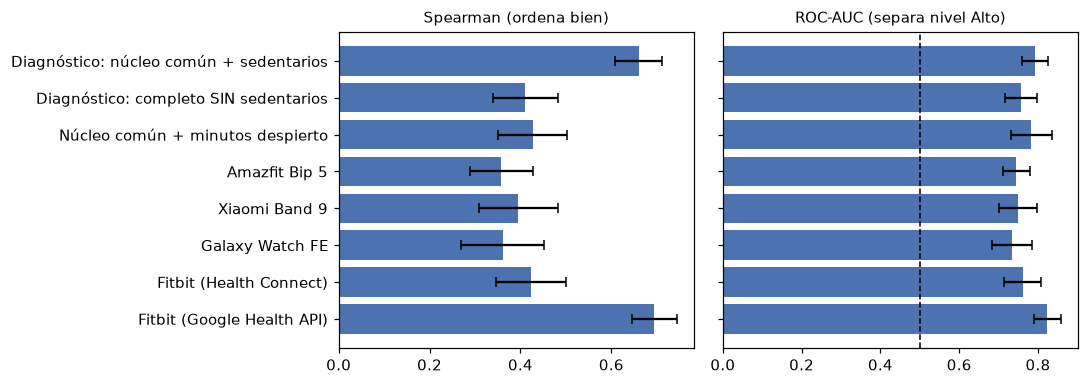

In [3]:
names = list(res)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for a, key, title in zip(ax, ["spearman", "roc_alto"], ["Spearman (ordena bien)", "ROC-AUC (separa nivel Alto)"]):
    a.barh(names, [res[n][0][key] for n in names], xerr=[res[n][1][key] for n in names], color="#4C72B0", capsize=3)
    a.axvline(0.5 if key == "roc_alto" else 0, color="k", ls="--", lw=1)
    a.set_title(title, fontsize=10); a.invert_yaxis()
plt.tight_layout(); plt.show()

## Parte B — Prototipo de la capa de estandarización

**Idea:** cada marca entrega los datos con nombres y unidades distintos y con datos sucios. La capa hace, en orden:

1. **Adaptador por marca:** renombra columnas y convierte unidades (por ejemplo segundos a minutos) al formato común.
2. **Derivar lo que falta:** la eficiencia no siempre llega; se calcula como `dormido / tiempo en cama × 100`.
3. **Filtrar valores imposibles:** pulso de 300, pasos negativos o de 250,000, minutos de sueño negativos. Se descartan.
4. **Quitar duplicados por día:** si el teléfono y el reloj registran el mismo día, se queda un solo registro
   (en pasos, el mayor).
5. **Detectar qué variables hay:** una variable cuenta si tiene al menos 10 días válidos; menos de 10 noches de sueño
   no alcanza para estimar.
6. **Elegir el modelo:** el perfil más completo cuyas variables estén todas disponibles.
7. **Estimar y armar la salida:** nivel Leve / Moderado / Alto (regla fija), índice, rango de incertidumbre,
   qué perfil se usó y qué faltó.

**Cómo se prueba:** con datos reales de personas de LifeSnaps, se generan "exportaciones" al estilo de cada marca, con
duplicados y valores basura inyectados, y se pasan por la capa. Comprobaciones: (a) limpiar datos sucios da lo mismo
que limpiar datos limpios, (b) se elige el perfil correcto, (c) una persona con pocas noches se rechaza. Esto prueba el
**software**, no cómo miden los relojes.

In [4]:
RANGES = {"minutesAsleep": (30, 1000), "minutesAwake": (0, 600), "sleep_efficiency": (30, 100), "resting_hr": (30, 120),
          "steps": (0, 80000), "sedentary_minutes": (0, 1440), "spo2": (70, 100), "rmssd": (1, 300),
          "full_sleep_breathing_rate": (5, 40), "nremhr": (30, 120), "minutesToFallAsleep": (0, 240)}
out_real = sum(int((raw37[c].notna() & ~raw37[c].between(*RANGES[c])).sum()) for c in RANGES)
print(f"Valores reales de LifeSnaps fuera de los rangos del filtro: {out_real} de {int(raw37[list(RANGES)].notna().sum().sum())}")

# --- adaptadores: cómo "habla" cada marca (simulado) ---
ADAPTERS = {
    "Fitbit (Google Health API)": dict(rename={}, scale={}),
    "Fitbit (Health Connect)": dict(rename={}, scale={}),
    "Galaxy Watch FE": dict(rename={"sleep_duration_s": "minutesAsleep", "time_in_bed_s": "time_in_bed", "hr_resting_bpm": "resting_hr",
                                    "step_count": "steps", "spo2_pct": "spo2"}, scale={"minutesAsleep": 1 / 60, "time_in_bed": 1 / 60}),
    "Xiaomi Band 9": dict(rename={"sleep_min": "minutesAsleep", "time_in_bed_min": "time_in_bed", "hr_rest": "resting_hr"}, scale={}),
    "Amazfit Bip 5": dict(rename={"sleep_min": "minutesAsleep", "time_in_bed_min": "time_in_bed", "hr_rest": "resting_hr"}, scale={}),
}
STEP_NAMES, HR_NAMES, SLEEP_NAMES = {"steps", "step_count"}, {"resting_hr", "hr_resting_bpm", "hr_rest"}, {"minutesAsleep", "sleep_duration_s", "sleep_min"}


def export_for_brand(g, brand):
    """Simula lo que entregaría la marca: mismas mediciones, otros nombres y unidades."""
    d = g[["date"]].copy()
    tib = g["minutesAsleep"] * 100 / g["sleep_efficiency"]          # tiempo en cama implícito
    if brand.startswith("Fitbit"):
        for v in PROFILES[brand]:
            d[v] = g[v]
    elif brand == "Galaxy Watch FE":
        d["sleep_duration_s"], d["time_in_bed_s"] = g["minutesAsleep"] * 60, tib * 60
        d["hr_resting_bpm"], d["step_count"], d["spo2_pct"] = g["resting_hr"], g["steps"], g["spo2"]
    elif brand == "Xiaomi Band 9":
        d["sleep_min"], d["time_in_bed_min"], d["hr_rest"], d["steps"] = g["minutesAsleep"], tib, g["resting_hr"], g["steps"]
    elif brand == "Amazfit Bip 5":
        d["sleep_min"], d["time_in_bed_min"], d["hr_rest"] = g["minutesAsleep"], tib, g["resting_hr"]
    return d


def make_dirty(exp, seed):
    """Agrega duplicados (p. ej. teléfono + reloj) y filas con valores imposibles."""
    rng = np.random.default_rng(seed)
    n = len(exp)
    dup = exp.iloc[rng.choice(n, size=max(1, int(0.06 * n)), replace=False)].copy()
    for c in dup.columns:
        if c in STEP_NAMES:
            dup[c] = dup[c] * 0.97
    junk = exp.iloc[rng.choice(n, size=max(1, int(0.04 * n)), replace=False)].copy()
    for c in junk.columns:
        junk[c] = 300 if c in HR_NAMES else (250000 if c in STEP_NAMES else (-5 if c in SLEEP_NAMES else junk[c]))
    dirty = pd.concat([exp, dup, junk]).sample(frac=1, random_state=int(rng.integers(1_000_000))).reset_index(drop=True)
    return dirty, len(dup), len(junk)


def standardize(export, brand):
    """Pasos 1-5 de la capa: adaptador, derivar, filtrar, deduplicar, detectar variables."""
    ad = ADAPTERS[brand]
    d = export.rename(columns=ad["rename"]).copy()
    for c, f in ad["scale"].items():
        d[c] = d[c] * f
    if "time_in_bed" in d and "sleep_efficiency" not in d:
        d["sleep_efficiency"] = d["minutesAsleep"] / d["time_in_bed"] * 100
    rows_in, bad = len(d), 0
    for c, (lo, hi) in RANGES.items():
        if c in d:
            m = d[c].notna() & ~d[c].between(lo, hi)
            bad += int(m.sum()); d.loc[m, c] = np.nan
    vars_present = [c for c in FULL if c in d]
    d = d.groupby("date", as_index=False).agg({c: ("max" if c == "steps" else "first") for c in vars_present})
    nights = int(d["minutesAsleep"].notna().sum()) if "minutesAsleep" in d else 0
    avail = {v for v in vars_present if d[v].notna().sum() >= MIN_NIGHTS}
    report = {"rows_received": rows_in, "rows_after_dedup": len(d), "impossible_values_discarded": bad}
    return d, avail, nights, report


def person_feats(d, vs):
    return pd.Series({fname(v, s): (d[v].mean() if s == "mean" else d[v].std()) for v in vs for s in ("mean", "std")})


def choose_profile(avail):
    ok = [(len(v), k) for k, v in PROFILES.items() if set(v) <= avail]
    return max(ok)[1] if ok else None


print("Perfil elegido si hay las 11:", choose_profile(set(FULL)), "| solo sueño+pulso+eficiencia:", choose_profile({"minutesAsleep", "sleep_efficiency", "resting_hr"}),
      "| solo sueño:", choose_profile({"minutesAsleep"}))

Valores reales de LifeSnaps fuera de los rangos del filtro: 102 de 24105
Perfil elegido si hay las 11: Fitbit (Google Health API) | solo sueño+pulso+eficiencia: Amazfit Bip 5 | solo sueño: None


### Incertidumbre de cada perfil
Para el rango de la salida se usan los errores de estimación de cada perfil sobre personas que el modelo no vio
(leave-one-out): percentiles 5 y 95 de los errores pasados.

In [5]:
def fit_rf(Xtr, ytr):
    return RandomForestRegressor(n_estimators=300, max_depth=5, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)


loo_q = {}
for name, vs in PROFILES.items():
    cols, pred = feat_cols(vs), np.zeros(len(person))
    for i in range(len(person)):
        tr = person.index != i
        pred[i] = fit_rf(person.loc[tr, cols], y[tr]).predict(person.loc[[i], cols])[0]
    loo_q[name] = tuple(np.quantile(y.values - pred, [0.05, 0.95]))
    print(f"{name:28s} errores pasados 5%–95%: {loo_q[name][0]:+.3f} a {loo_q[name][1]:+.3f}  (Spearman LOO {spearmanr(y, pred).correlation:.2f})")

Fitbit (Google Health API)   errores pasados 5%–95%: -0.210 a +0.301  (Spearman LOO 0.71)


Fitbit (Health Connect)      errores pasados 5%–95%: -0.186 a +0.335  (Spearman LOO 0.41)


Galaxy Watch FE              errores pasados 5%–95%: -0.191 a +0.346  (Spearman LOO 0.32)


Xiaomi Band 9                errores pasados 5%–95%: -0.189 a +0.346  (Spearman LOO 0.35)


Amazfit Bip 5                errores pasados 5%–95%: -0.209 a +0.346  (Spearman LOO 0.38)


In [6]:
def estimate(export, brand, i):
    """Pasos 5-7: elegir modelo, estimar y armar la salida. i = persona que se deja fuera del entrenamiento."""
    d, avail, nights, report = standardize(export, brand)
    out = {"brand": brand, "nights_with_sleep_data": nights, "cleaning_report": report}
    if nights < MIN_NIGHTS:
        return {**out, "status": "insufficient_data", "message": f"Solo {nights} noches con dato de sueño; se necesitan al menos {MIN_NIGHTS}."}
    prof = choose_profile(avail)
    if prof is None:
        return {**out, "status": "insufficient_variables", "message": "Faltan las variables mínimas (sueño, eficiencia, pulso en reposo)."}
    vs, cols = PROFILES[prof], feat_cols(PROFILES[prof])
    tr = person.index != i
    f = person_feats(d, vs)
    f = f.fillna(person.loc[tr, cols].median())[cols]
    est = float(fit_rf(person.loc[tr, cols], y[tr]).predict(f.to_frame().T)[0])
    lo, hi = float(np.clip(est + loo_q[prof][0], 0, 1)), float(np.clip(est + loo_q[prof][1], 0, 1))
    order = ["Leve", "Moderado", "Alto"]
    return {**out, "status": "ok", "model_profile": prof, "risk_level": risk_level(est),
            "estimated_risk_index": round(est, 3), "estimated_range_90": [round(lo, 3), round(hi, 3)],
            "levels_in_range": [k for k in order if order.index(risk_level(lo)) <= order.index(k) <= order.index(risk_level(hi))],
            "variables_missing_vs_full_model": [v for v in FULL if v not in vs]}


# --- personas de prueba ---
nights_all = raw37.groupby(COL_ID)["minutesAsleep"].count()
few = nights_all.idxmin()
enough = np.array([nights_all[p] >= MIN_NIGHTS for p in ids])      # solo personas con noches suficientes
print(f"Personas con menos de {MIN_NIGHTS} noches con dato de sueño (la capa las rechaza): {int((~enough).sum())} de {len(ids)}")
demo = {"Mayor riesgo real": int(np.argmax(np.where(enough, y, -1))),
        "Riesgo intermedio": int(np.argmin(np.where(enough, np.abs(y * SCALE - 7.5), 99))),
        "Menor riesgo real": int(np.argmin(np.where(enough, y, 99))),
        f"Pocas noches ({nights_all.min()})": int(np.where(ids == few)[0][0])}

rows = []
for label, i in demo.items():
    g = raw37[raw37[COL_ID] == ids[i]]
    line = {"Persona de prueba": label, "Nivel real (proxy)": risk_level(y[i])}
    for brand in PROFILES:
        dirty, _, _ = make_dirty(export_for_brand(g, brand), seed=i)
        o = estimate(dirty, brand, i)
        line[brand] = f"{o['risk_level']} ({o['estimated_risk_index']})" if o["status"] == "ok" else "RECHAZADA: pocas noches"
    rows.append(line)
pd.DataFrame(rows).set_index("Persona de prueba")

Personas con menos de 10 noches con dato de sueño (la capa las rechaza): 2 de 37


,Nivel real (proxy),Fitbit (Google Health API),Fitbit (Health Connect),Galaxy Watch FE,Xiaomi Band 9,Amazfit Bip 5
Persona de prueba,,,,,,
Mayor riesgo real,Alto,Alto (0.53),Alto (0.509),Alto (0.519),Alto (0.531),Alto (0.534)
Riesgo intermedio,Moderado,Moderado (0.371),Moderado (0.371),Moderado (0.371),Moderado (0.371),Moderado (0.413)
Menor riesgo real,Leve,Moderado (0.285),Moderado (0.383),Moderado (0.401),Moderado (0.407),Moderado (0.268)
Pocas noches (3),Alto,RECHAZADA: pocas noches,RECHAZADA: pocas noches,RECHAZADA: pocas noches,RECHAZADA: pocas noches,RECHAZADA: pocas noches


### Comprobaciones de la capa

1. **¿Limpiar datos sucios da lo mismo que limpiar datos limpios?** Se comparan las variables por persona calculadas de
   ambas versiones (debe dar diferencia 0).
2. **¿Se elige el perfil correcto?** Cada marca debe terminar con su propio perfil (con las salvedades de datos
   faltantes de cada persona).
3. **Reporte de limpieza** de un caso: cuántos duplicados y valores imposibles se descartaron.

In [7]:
# 1) limpio vs sucio
max_diffs = []
for brand in PROFILES:
    for i in [demo["Mayor riesgo real"], demo["Riesgo intermedio"], demo["Menor riesgo real"]]:
        g = raw37[raw37[COL_ID] == ids[i]]
        exp = export_for_brand(g, brand)
        dirty, _, _ = make_dirty(exp, seed=i)
        d1, a1, *_ = standardize(exp, brand); d2, a2, *_ = standardize(dirty, brand)
        vs = sorted(a1)
        f1, f2 = person_feats(d1, vs), person_feats(d2, vs)
        max_diffs.append(float(np.nanmax(np.abs(f1.values - f2.values))))
        assert a1 == a2
print(f"1) Diferencia máxima entre variables (limpio vs sucio) en {len(max_diffs)} pruebas: {max(max_diffs):.2e}")

# 2) perfil elegido por marca y persona
chosen = {b: [] for b in PROFILES}
for label, i in list(demo.items())[:3]:
    g = raw37[raw37[COL_ID] == ids[i]]
    for brand in PROFILES:
        _, avail, _, _ = standardize(export_for_brand(g, brand), brand)
        chosen[brand].append(choose_profile(avail))
print("2) Perfil elegido (mayor / intermedio / menor riesgo):")
for b, c in chosen.items():
    print(f"   {b:28s} -> {c}")

# 3) reporte de limpieza de un caso y salida completa
i = demo["Mayor riesgo real"]; g = raw37[raw37[COL_ID] == ids[i]]
dirty, n_dup, n_junk = make_dirty(export_for_brand(g, "Galaxy Watch FE"), seed=i)
print(f"\n3) Galaxy Watch FE: se inyectaron {n_dup} duplicados y {n_junk} filas con valores imposibles")
print(json.dumps(estimate(dirty, "Galaxy Watch FE", i), indent=2, ensure_ascii=False))

1) Diferencia máxima entre variables (limpio vs sucio) en 15 pruebas: 0.00e+00
2) Perfil elegido (mayor / intermedio / menor riesgo):
   Fitbit (Google Health API)   -> ['Fitbit (Google Health API)', 'Xiaomi Band 9', 'Fitbit (Google Health API)']
   Fitbit (Health Connect)      -> ['Fitbit (Health Connect)', 'Xiaomi Band 9', 'Fitbit (Health Connect)']
   Galaxy Watch FE              -> ['Galaxy Watch FE', 'Xiaomi Band 9', 'Galaxy Watch FE']
   Xiaomi Band 9                -> ['Xiaomi Band 9', 'Xiaomi Band 9', 'Xiaomi Band 9']
   Amazfit Bip 5                -> ['Amazfit Bip 5', 'Amazfit Bip 5', 'Amazfit Bip 5']

3) Galaxy Watch FE: se inyectaron 8 duplicados y 5 filas con valores imposibles


{
  "brand": "Galaxy Watch FE",
  "nights_with_sleep_data": 20,
  "cleaning_report": {
    "rows_received": 147,
    "rows_after_dedup": 134,
    "impossible_values_discarded": 16
  },
  "status": "ok",
  "model_profile": "Galaxy Watch FE",
  "risk_level": "Alto",
  "estimated_risk_index": 0.519,
  "estimated_range_90": [
    0.328,
    0.866
  ],
  "levels_in_range": [
    "Moderado",
    "Alto"
  ],
  "variables_missing_vs_full_model": [
    "rmssd",
    "nremhr",
    "full_sleep_breathing_rate",
    "minutesToFallAsleep",
    "minutesAwake",
    "sedentary_minutes"
  ]
}


## Lectura de los resultados (ensayo, no es ley)

**Parte A — el costo de la universalidad**
- Con solo las variables que entregaría cada reloj, el modelo pierde: Spearman de **0.70 a 0.36–0.43** y ROC-AUC (nivel Alto)
  de **0.82 a 0.73–0.76**. Sigue por encima del azar (0.5) y del baseline en error (0.14 contra 0.165), pero es bastante menos.
- **La pérdida viene casi toda de un solo dato: los minutos sedentarios.** Sin ellos (10 variables) el Spearman es 0.41; el
  núcleo común **con** sedentarios llega a 0.66, casi el del modelo completo. HRV, respiración, SpO2 y el resto aportan muy poco
  en este proxy.
- **Ojo:** no sabemos si los minutos sedentarios pesan por ser una señal real de sueño o porque el puntaje de Fitbit (proxy) se
  construye en parte con actividad (el Stress Score usa pulso, sueño y actividad). Hay que repetirlo con el PSQI.
- **Entre marcas no hay diferencias que se puedan afirmar:** Galaxy Watch, Xiaomi y Amazfit quedan dentro del ruido
  (± 0.05 a 0.09). Agregar minutos despierto sube el ROC-AUC 0.03, también dentro del ruido.

**Parte B — la capa de estandarización**
- Limpiar datos sucios da **exactamente lo mismo** que limpiar datos limpios (diferencia 0 en 15 pruebas). Es esperable por cómo
  se armó la prueba: demuestra que el código funciona, no que resista todos los problemas de datos reales.
- **Elige bien el perfil**, y cuando a una persona le falta una variable (por ejemplo SpO2 en el caso intermedio con Galaxy)
  **baja al perfil siguiente en vez de fallar**.
- **Rechaza a 2 de 37 personas** por tener menos de 10 noches, y dice el motivo.
- La persona de menor riesgo real sale "Moderado" con todos los perfiles: es la contracción hacia el centro que ya vimos.

**Qué implica**
- Un solo modelo con el núcleo común es viable en software, pero **el costo predictivo es real** y depende de los minutos
  sedentarios. Opciones: aproximarlos (pasos por hora o intensidad de actividad de Health Connect; es una hipótesis sin probar) o
  aceptar la pérdida.
- **Límites:** solo hay datos de Fitbit, así que esto NO mide cómo difieren los algoritmos de cada marca; los perfiles vienen de
  fuentes parcialmente secundarias; la etiqueta es un proxy; n = 37.
- **Siguientes pasos:** verificación física de qué escribe cada reloj en Health Connect, buscar datos de otras marcas y probar
  la aproximación de sedentarios.